# Mejor modelo de regresión

**Aprendizaje Automático 1 — Tecnicatura en Inteligencia Artificial (FCEIA, UNR)**

**Integrantes:** Calabozo · Darruiz · Di Carlo · Giuntoli

---

Buscamos el modelo con menor error para predecir `MEDV`, sin limitarnos a la regresión lineal.
Partimos de los mismos datos y la misma división 80/20 que el trabajo principal
(`TP-regresion-AA1.ipynb`), para poder comparar.

Todas las decisiones se toman con **validación cruzada** sobre el conjunto de entrenamiento. El
conjunto de prueba se usa **una sola vez**, al final, para medir el error del modelo elegido.

## 1. Configuración

In [1]:
# Bibliotecas de datos y gráficos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import loguniform, randint, uniform

# Herramientas de scikit-learn
from sklearn.model_selection import (train_test_split, RepeatedKFold,
                                     cross_val_score, GridSearchCV,
                                     RandomizedSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                              GradientBoostingRegressor,
                              HistGradientBoostingRegressor, VotingRegressor)
from sklearn.inspection import permutation_importance
from sklearn.metrics import (mean_squared_error, root_mean_squared_error,
                             mean_absolute_error, r2_score)

SEMILLA = 42

# Validación cruzada de 5 particiones repetida 3 veces con distintas
# mezclas: con pocas filas, repetir hace más estable la comparación
CV = RepeatedKFold(n_splits=5, n_repeats=3, random_state=SEMILLA)
METRICA_CV = 'neg_root_mean_squared_error'

sns.set_theme(style='whitegrid')


def metricas(y_real, y_pred):
    """MSE, RMSE, MAE y R² de un conjunto de predicciones."""
    return {'MSE': mean_squared_error(y_real, y_pred),
            'RMSE': root_mean_squared_error(y_real, y_pred),
            'MAE': mean_absolute_error(y_real, y_pred),
            'R²': r2_score(y_real, y_pred)}

## 2. Datos

In [2]:
# Misma preparación que el trabajo principal: se descartan las filas sin
# MEDV y se usa la misma división 80/20 con la misma semilla
datos = (pd.read_csv('data/house-prices-tp.csv')
         .dropna(subset=['MEDV']).reset_index(drop=True))
X = datos.drop(columns='MEDV')
y = datos['MEDV']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEMILLA)


def rmse_cv(modelo):
    """RMSE del modelo en cada una de las 15 particiones de validación."""
    return -cross_val_score(modelo, X_train, y_train, cv=CV,
                            scoring=METRICA_CV, n_jobs=-1)


print(f'Entrenamiento: {len(X_train)} filas   Prueba: {len(X_test)} filas')

Entrenamiento: 428 filas   Prueba: 107 filas


## 3. Comparación inicial

Probamos ocho tipos de modelo con hiperparámetros por defecto. Todos imputan con la mediana (salvo
`HistGradientBoosting`, que acepta faltantes), y los que dependen de la escala de las variables
también estandarizan.

In [3]:
# Candidatos con hiperparámetros por defecto
def imputar():
    return SimpleImputer(strategy='median')


candidatos = {
    'LinearRegression': Pipeline([
        ('imp', imputar()), ('esc', StandardScaler()),
        ('reg', LinearRegression())]),
    'Ridge + términos cuadráticos': Pipeline([
        ('imp', imputar()), ('esc', StandardScaler()),
        ('cuad', PolynomialFeatures(2, include_bias=False)),
        ('esc2', StandardScaler()),
        ('reg', RidgeCV(alphas=np.logspace(-2, 3, 30)))]),
    'KNN': Pipeline([
        ('imp', imputar()), ('esc', StandardScaler()),
        ('reg', KNeighborsRegressor())]),
    'SVR': Pipeline([
        ('imp', imputar()), ('esc', StandardScaler()), ('reg', SVR())]),
    'RandomForest': Pipeline([
        ('imp', imputar()),
        ('reg', RandomForestRegressor(n_estimators=500,
                                      random_state=SEMILLA))]),
    'ExtraTrees': Pipeline([
        ('imp', imputar()),
        ('reg', ExtraTreesRegressor(n_estimators=500,
                                    random_state=SEMILLA))]),
    'GradientBoosting': Pipeline([
        ('imp', imputar()),
        ('reg', GradientBoostingRegressor(random_state=SEMILLA))]),
    'HistGradientBoosting': HistGradientBoostingRegressor(
        random_state=SEMILLA),
}

errores_cv = {nombre: rmse_cv(modelo) for nombre, modelo in candidatos.items()}
comparacion = pd.DataFrame({
    'RMSE (CV)': {n: e.mean() for n, e in errores_cv.items()},
    'Desvío entre particiones': {n: e.std() for n, e in errores_cv.items()},
}).sort_values('RMSE (CV)')
display(comparacion.round(3))

,RMSE (CV),Desvío entre particiones
ExtraTrees,4.339,0.621
RandomForest,4.532,0.542
GradientBoosting,4.535,0.521
HistGradientBoosting,4.649,0.685
Ridge + términos cuadráticos,4.710,0.723
KNN,5.405,0.705
LinearRegression,5.886,0.646
SVR,6.130,0.926


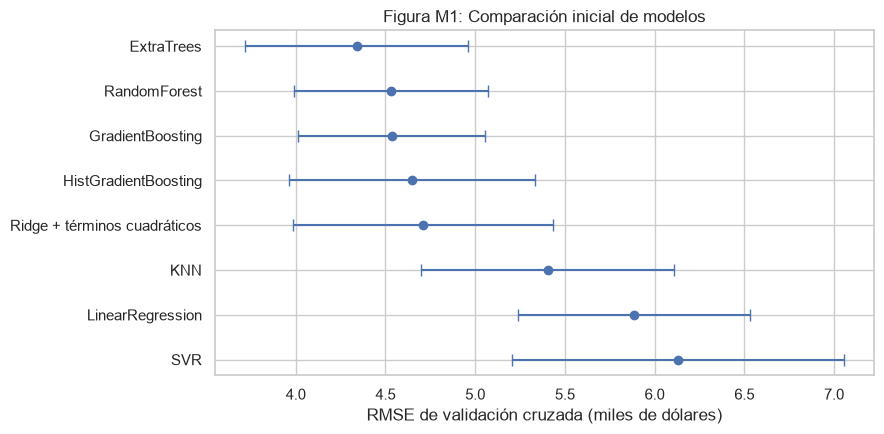

In [4]:
# RMSE medio de cada candidato, con ±1 desvío entre particiones
orden = comparacion.iloc[::-1]
plt.figure(figsize=(9, 4.5))
plt.errorbar(orden['RMSE (CV)'], orden.index,
             xerr=orden['Desvío entre particiones'], fmt='o', capsize=4)
plt.xlabel('RMSE de validación cruzada (miles de dólares)')
plt.title('Figura M1: Comparación inicial de modelos')
plt.tight_layout()
plt.show()

Los ensambles de árboles quedan primeros (RMSE entre 4.34 y 4.65), bastante por debajo de
`LinearRegression` (5.89). Agregarle términos cuadráticos a Ridge también mejora mucho (4.71), lo que
confirma que la relación con el precio no es lineal. `SVR` queda último con los valores por
defecto.

## 4. Ajuste de hiperparámetros

Ajustamos `RandomForest` y `ExtraTrees`, `GradientBoosting` (el mejor de los dos de *boosting*) y
`SVR`, que con los valores por defecto queda último pero depende mucho de sus hiperparámetros.
`Ridge` con términos cuadráticos ya elige su `alpha` internamente (`RidgeCV`) y queda detrás de los
árboles, así que no lo seguimos.

In [5]:
# Búsqueda de hiperparámetros con la misma validación cruzada
def buscar_grilla(modelo, grilla):
    return GridSearchCV(modelo, grilla, cv=CV, scoring=METRICA_CV, n_jobs=-1)


grilla_arboles = {'reg__max_features': [0.2, 0.33, 0.5, 0.75, 1.0],
                  'reg__min_samples_leaf': [1, 2, 4]}
busquedas = {
    'RandomForest': buscar_grilla(candidatos['RandomForest'],
                                  grilla_arboles),
    'ExtraTrees': buscar_grilla(candidatos['ExtraTrees'], grilla_arboles),
    # GradientBoosting tiene más hiperparámetros: probamos 40 combinaciones
    # al azar en lugar de la grilla completa
    'GradientBoosting': RandomizedSearchCV(
        candidatos['GradientBoosting'],
        {'reg__n_estimators': randint(100, 800),
         'reg__learning_rate': loguniform(0.01, 0.2),
         'reg__max_depth': [2, 3, 4, 5, 6],
         'reg__subsample': uniform(0.6, 0.4),
         'reg__min_samples_leaf': [1, 3, 5, 10]},
        n_iter=40, cv=CV, scoring=METRICA_CV, n_jobs=-1,
        random_state=SEMILLA),
    'SVR': buscar_grilla(candidatos['SVR'],
                         {'reg__C': [30, 100, 300, 1000],
                          'reg__gamma': [0.01, 0.03, 0.1],
                          'reg__epsilon': [0.5, 1.0, 2.0, 3.0]}),
}

filas = []
for nombre, busqueda in busquedas.items():
    busqueda.fit(X_train, y_train)
    filas.append({'Modelo': nombre,
                  'RMSE (CV) por defecto': errores_cv[nombre].mean(),
                  'RMSE (CV) ajustado': -busqueda.best_score_})
    parametros = {k.removeprefix('reg__'): (round(float(v), 3)
                                            if isinstance(v, float) else v)
                  for k, v in busqueda.best_params_.items()}
    print(f'{nombre:17s} {parametros}')
display(pd.DataFrame(filas).round(3))

RandomForest      {'max_features': 0.33, 'min_samples_leaf': 1}


ExtraTrees        {'max_features': 0.5, 'min_samples_leaf': 1}


GradientBoosting  {'learning_rate': 0.037, 'max_depth': 4, 'min_samples_leaf': 5, 'n_estimators': 340, 'subsample': 0.726}


SVR               {'C': 100, 'epsilon': 2.0, 'gamma': 0.03}


,Modelo,RMSE (CV) por defecto,RMSE (CV) ajustado
0,RandomForest,4.532,4.334
1,ExtraTrees,4.339,4.222
2,GradientBoosting,4.535,4.372
3,SVR,6.130,4.334


El ajuste mejora a los cuatro modelos. El cambio más grande es el de `SVR`, que pasa de 6.13 a
4.33. `ExtraTrees` queda como el mejor modelo individual (4.22). Como `RandomForest` es de la misma
familia y queda detrás, para el ensamble usamos solo `ExtraTrees`.

## 5. Ensamble

Combinamos el mejor modelo de cada familia promediando sus predicciones (`VotingRegressor`), y lo
comparamos partición por partición con cada modelo por separado.

In [6]:
# Promedio de las predicciones del mejor modelo de cada familia
ensamble = VotingRegressor([
    ('extra_trees', busquedas['ExtraTrees'].best_estimator_),
    ('gradient_boosting', busquedas['GradientBoosting'].best_estimator_),
    ('svr', busquedas['SVR'].best_estimator_),
])

errores_finales = {n: rmse_cv(busquedas[n].best_estimator_)
                   for n in ['ExtraTrees', 'GradientBoosting', 'SVR']}
errores_finales['Ensamble'] = rmse_cv(ensamble)

e = errores_finales['Ensamble']
display(pd.DataFrame({
    'RMSE (CV)': {n: v.mean() for n, v in errores_finales.items()},
    'Desvío entre particiones': {n: v.std()
                                 for n, v in errores_finales.items()},
    'Particiones en que el ensamble es mejor': {
        n: f'{(e < v).sum()} de {len(v)}' if n != 'Ensamble' else '—'
        for n, v in errores_finales.items()},
}).round(3))

,RMSE (CV),Desvío entre particiones,Particiones en que el ensamble es mejor
ExtraTrees,4.222,0.568,10 de 15
GradientBoosting,4.372,0.615,14 de 15
SVR,4.334,0.683,12 de 15
Ensamble,4.062,0.612,—


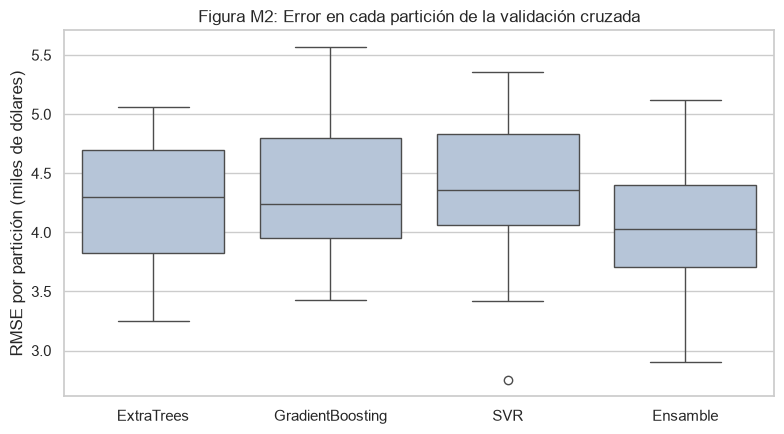

In [7]:
# RMSE de las 15 particiones de validación de cada modelo
plt.figure(figsize=(8, 4.5))
sns.boxplot(data=pd.DataFrame(errores_finales), color='lightsteelblue')
plt.ylabel('RMSE por partición (miles de dólares)')
plt.title('Figura M2: Error en cada partición de la validación cruzada')
plt.tight_layout()
plt.show()

El ensamble tiene el menor RMSE de validación cruzada (4.06) y le gana a cada modelo en la mayoría
de las particiones: a `ExtraTrees` en 10 de 15, a `SVR` en 12 y a `GradientBoosting` en 14. La
mejora frente a `ExtraTrees` es chica (0.16 k\$), pero consistente. Por eso es el modelo
elegido.

## 6. Evaluación final en prueba

El modelo elegido es el **ensamble**. Recién ahora medimos el error en el conjunto de prueba, junto
con `LinearRegression` como referencia y los modelos que forman el ensamble.

In [8]:
# Métricas de entrenamiento y prueba de cada modelo
finales = {
    'LinearRegression': candidatos['LinearRegression'],
    'ExtraTrees': busquedas['ExtraTrees'].best_estimator_,
    'GradientBoosting': busquedas['GradientBoosting'].best_estimator_,
    'SVR': busquedas['SVR'].best_estimator_,
    'Ensamble': ensamble,
}
errores_finales['LinearRegression'] = errores_cv['LinearRegression']

filas = []
for nombre, modelo in finales.items():
    modelo.fit(X_train, y_train)
    fila = {'Modelo': nombre,
            'RMSE (CV)': errores_finales[nombre].mean()}
    for conjunto, X_c, y_c in [('Train', X_train, y_train),
                               ('Test', X_test, y_test)]:
        for metrica, valor in metricas(y_c, modelo.predict(X_c)).items():
            fila[f'{metrica} ({conjunto})'] = valor
    filas.append(fila)
resultados = pd.DataFrame(filas).set_index('Modelo')
display(resultados.round(3))

,RMSE (CV),MSE (Train),RMSE (Train),MAE (Train),R² (Train),MSE (Test),RMSE (Test),MAE (Test),R² (Test)
Modelo,,,,,,,,,
LinearRegression,5.886,30.787,5.549,3.849,0.663,57.882,7.608,4.690,0.304
ExtraTrees,4.222,0.000,0.001,0.000,1.000,20.190,4.493,2.440,0.757
GradientBoosting,4.372,1.409,1.187,0.866,0.985,27.269,5.222,2.719,0.672
SVR,4.334,8.062,2.839,1.882,0.912,21.396,4.626,2.734,0.743
Ensamble,4.062,1.559,1.249,0.842,0.983,21.201,4.604,2.502,0.745


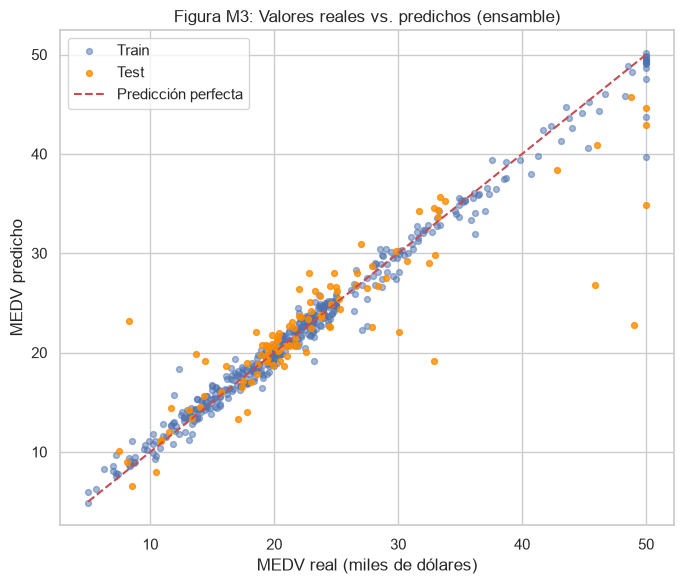

In [9]:
# Valores reales contra predichos por el ensamble
plt.figure(figsize=(7, 6))
plt.scatter(y_train, ensamble.predict(X_train), s=18, alpha=0.5,
            label='Train')
plt.scatter(y_test, ensamble.predict(X_test), s=18, alpha=0.8,
            color='darkorange', label='Test')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--',
         label='Predicción perfecta')
plt.xlabel('MEDV real (miles de dólares)')
plt.ylabel('MEDV predicho')
plt.title('Figura M3: Valores reales vs. predichos (ensamble)')
plt.legend()
plt.tight_layout()
plt.show()

El ensamble baja el RMSE de prueba de 7.61 k\$ (`LinearRegression`) a **4.60 k\$**, y el R² de 0.30
a **0.75**. En la **Figura M3**, los puntos de prueba siguen de cerca la diagonal, con algunos
errores grandes aislados.

En prueba, `ExtraTrees` solo da un error algo menor que el ensamble (4.49 frente a 4.60). No
cambiamos la elección: la diferencia es chica frente al desvío entre particiones (0.6 k\$), y elegir
mirando el conjunto de prueba es lo que el trabajo principal muestra que no hay que hacer.

El error de entrenamiento de los árboles es casi nulo (`ExtraTrees` reproduce los datos que vio),
así que acá no sirve para medir sobreajuste; lo que cuenta es la validación cruzada y la prueba.
Como en el trabajo principal, todos los modelos tienen más error en prueba que en validación
cruzada.

## 7. Variables más importantes

Medimos la importancia de cada variable por permutación: cuánto aumenta el RMSE en prueba si se
mezclan al azar los valores de esa variable.

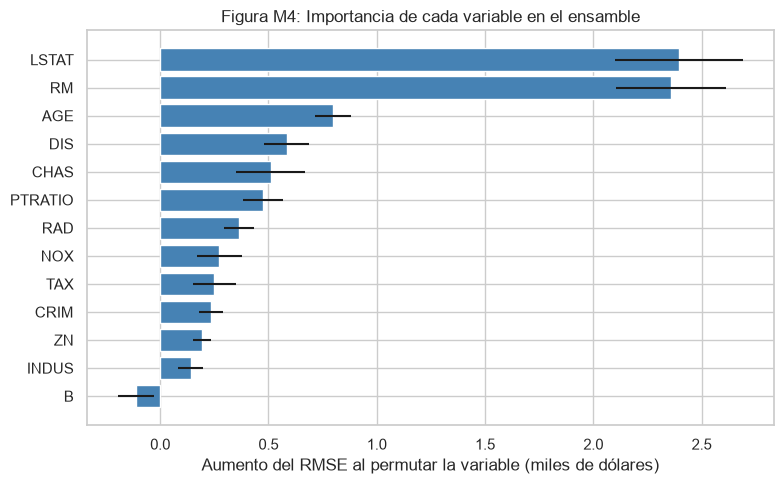

,Aumento del RMSE,Desvío
LSTAT,2.39,0.30
RM,2.36,0.25
AGE,0.80,0.08
DIS,0.58,0.11
CHAS,0.51,0.16
PTRATIO,0.48,0.09
RAD,0.36,0.07
NOX,0.27,0.10
TAX,0.25,0.10
CRIM,0.23,0.06


In [10]:
# Importancia por permutación sobre el conjunto de prueba
importancia = permutation_importance(
    ensamble, X_test, y_test, scoring=METRICA_CV, n_repeats=20,
    random_state=SEMILLA, n_jobs=-1)
importancias = pd.DataFrame({'Aumento del RMSE': importancia.importances_mean,
                             'Desvío': importancia.importances_std},
                            index=X.columns).sort_values('Aumento del RMSE')

plt.figure(figsize=(8, 5))
plt.barh(importancias.index, importancias['Aumento del RMSE'],
         xerr=importancias['Desvío'], color='steelblue')
plt.xlabel('Aumento del RMSE al permutar la variable (miles de dólares)')
plt.title('Figura M4: Importancia de cada variable en el ensamble')
plt.tight_layout()
plt.show()

display(importancias.iloc[::-1].round(2))

`LSTAT` y `RM` son, por lejos, las variables más importantes: mezclar cualquiera de las dos sube el
RMSE en unos 2.4 k\$, en línea con las correlaciones del trabajo principal. Les siguen `AGE`, `DIS`,
`CHAS` y `PTRATIO`. Mezclar `B` no empeora el modelo (−0.11), así que prácticamente no la usa.

## 8. Conclusión

- El mejor modelo es un **ensamble** que promedia `ExtraTrees`, `GradientBoosting` y `SVR`, con
  hiperparámetros elegidos por validación cruzada.
- En prueba tiene un RMSE de **4.60 k\$** y un R² de **0.75**, frente a 7.61 k\$ y 0.30 de
  `LinearRegression`: el error baja casi un 40 %.
- La mejora viene de modelos que capturan relaciones no lineales, lo que confirma la conclusión del
  trabajo principal: el límite de la regresión lineal estaba en la forma del modelo.
- A cambio se pierde interpretabilidad: no hay coeficientes, y la importancia de cada variable hay
  que medirla aparte (Figura M4).